In [1]:
from mymodels import AlexNet, mobilenet_v3_small, MySqueezeNet
from torch import load, no_grad, cat
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from dataUtils import *
import matplotlib
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
%matplotlib inline

In [9]:
models = {'alex':AlexNet(),'mobile':mobilenet_v3_small(),'squeeze':MySqueezeNet()}

In [5]:
real = []
areas = []
predictions = {'alex':[],'mobile':[],'squeeze':[]}
for i,model in enumerate(models):   
    net = models[model]
    net.load_state_dict(load(f'models/{model}_net.pth',weights_only=True))
    net.eval()
    test_load = make_test_loader()
    with no_grad():
        for map,area,ate,are in test_load:
            yhat = net(map,area).squeeze(0).numpy()
            predictions[model] += [yhat]
            if i==0: 
                areas += [area]
                real += [cat([ate,are]).numpy()]

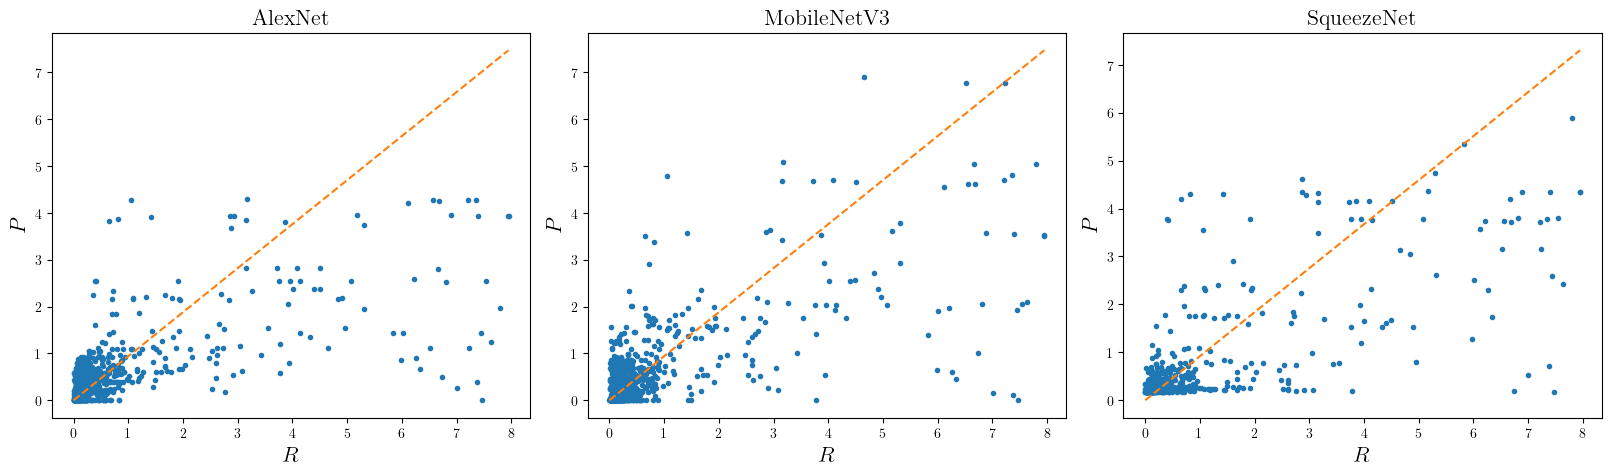

In [ ]:
_,axs = plt.subplots(1,3,figsize=(20,5))
plt.subplots_adjust(wspace=0.12)
for i,model in enumerate(models):
    Predicted = np.array([np.array(revert_data_norm(ate,are)) for ate,are in predictions[model]])
    Real = np.array([np.array(revert_data_norm(ate,are)) for ate,are in real])
    pAte = Predicted[:,0]
    pAre = Predicted[:,1]
    rAte = Real[:,0]
    rAre = Real[:,1]
    axs[i].plot(rAte, pAte,'.')
    axs[i].plot([0,max(rAte)],[0,max(np.abs(rAte-pAte))],'--')
    axs[i].set_ylabel('$P$', fontsize=16)
    axs[i].set_xlabel('$R$', fontsize=16)
    #axs[i].set_aspect('equal')
axs[0].set_title('AlexNet', fontsize=16)
axs[1].set_title('MobileNetV3', fontsize=16)
axs[2].set_title('SqueezeNet', fontsize=16)

### WITHOUT BROKEN RUNS

In [5]:
real = []
areas = []
predictions = {'alex':[],'mobile':[],'squeeze':[]}
for i,model in enumerate(models):   
    net = models[model]
    net.load_state_dict(load(f'models/{model}_net.pth',weights_only=True))
    net.eval()
    test_load = make_train_loader(batch_size=1,broken=False)
    with no_grad():
        for map,area,ate,are in test_load:
            yhat = net(map,area).squeeze(0).numpy()
            predictions[model] += [yhat]
            if i==0: 
                areas += [area]
                real += [cat([ate,are]).numpy()]

In [7]:
for i,model in enumerate(models):
    print(model)
    Predicted = np.array([np.array(revert_data_norm(ate,are)) for ate,are in predictions[model]])
    Real = np.array([np.array(revert_data_norm(ate,are)) for ate,are in real])
    pAte = Predicted[:,0]
    pAre = Predicted[:,1]
    rAte = Real[:,0]
    rAre = Real[:,1]
    R2_ate = r2_score(rAte,pAte)
    R2_are = r2_score(rAre,pAre)
    RMSE_ate = np.sqrt(mean_squared_error(rAte,pAte))
    RMSE_are = np.sqrt(mean_squared_error(rAre,pAre))
    NRMSE_ate = RMSE_ate/(pAte.max()-pAte.min())
    NRMSE_are = RMSE_are/(pAre.max()-pAre.min())
    print(f'ATE\n\tR2: {round(R2_ate,3)}\tRMSE: {round(RMSE_ate,3)}\tNRMSE: {round(NRMSE_ate,3)}\t')
    print(f'ARE\n\tR2: {round(R2_are,3)}\tRMSE: {round(RMSE_are,3)}\tNRMSE: {round(NRMSE_are,3)}\t')

alex
ATE
	R2: -1.024	RMSE: 0.309	NRMSE: 0.178	
ARE
	R2: -2.379	RMSE: 0.008	NRMSE: 0.149	
mobile
ATE
	R2: -2.227	RMSE: 0.391	NRMSE: 0.142	
ARE
	R2: -3.451	RMSE: 0.01	NRMSE: 0.088	
squeeze
ATE
	R2: -0.372	RMSE: 0.255	NRMSE: 0.154	
ARE
	R2: -1.582	RMSE: 0.007	NRMSE: 0.148	
